# Demographic Data and Election Data- Republican Vote Share

In this section, we examine how demographic and economic variables are associated with Republican vote share across California counties. 

We merge county-level voting data with demographic data and analyze relationships using correlation and visualization techniques. 

We focus on four key variables:
- Median age
- Median household income
- Racial composition
- Industry (agriculture employment)

Our goal is to identify which factors are most strongly associated with voting patterns.

In [1]:
import pandas as pd

## Step 1: Load Voting and Demographic Data
- Loaded cleaned California county voting dataset
- Loaded demographic dataset (ACS)
- Prepared both datasets for merging

In [2]:
voting = pd.read_csv("../data/clean_data/california_county_voting_cleaned.csv")
acs = pd.read_csv("../data/clean_data/ACS_final.csv")

In [5]:
print(voting.columns)
print(acs.columns)

Index(['county_name', 'county_fips', 'year', 'dem_share', 'rep_share',
       'margin', 'winner'],
      dtype='str')
Index(['county', 'median_age', 'pct_white', 'pct_black', 'pct_native',
       'pct_asian', 'pct_other', 'pct_hispanic', 'median_household_income',
       'unemployment_rate', 'pct_agriculture_mining', 'pct_construction',
       'pct_manufacturing', 'pct_wholesale_trade', 'pct_retail_trade',
       'pct_transportation_warehousing_utilities', 'pct_information',
       'pct_real_estate_rental_leasing', 'pct_admin_waste_services',
       'pct_health_care_social_assistance', 'pct_accommodation_food_services',
       'pct_other_services', 'pct_public_administration',
       'pct_bachelors_degree'],
      dtype='str')


In [7]:
acs["county"] = acs["county"].str.replace(" County", "")

## Step 2: Merge Voting and Demographic Data
- Merged datasets using county names
- Cleaned county labels to ensure proper matching
- Created a combined dataset containing both voting outcomes and demographic variables

In [8]:
df = pd.merge(voting, acs, left_on="county_name", right_on="county")

## Step 3: Select Key Variables
- Selected variables of interest:
  - Median age
  - Median household income
  - Percent white population
  - Percent employed in agriculture/mining
- Focused on these variables to test relationships with Republican vote share

In [11]:
variables = ["median_age", "median_household_income", "pct_white", "pct_agriculture_mining"]

for var in variables:
    print(var, df[var].corr(df["rep_share"]))

median_age 0.152759750176392
median_household_income -0.6696326224206147
pct_white 0.47666860932714805
pct_agriculture_mining 0.43234865380910026


## Step 5: Visualizing Relationships
- Created scatter plots to visualize relationships between variables and Republican vote share
- Added trend lines to highlight overall patterns
- Examined direction and strength of associations across counties

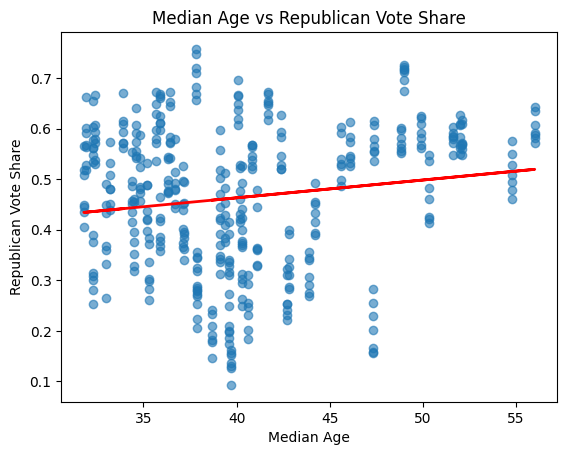

In [14]:
import numpy as np

x = df["median_age"]
y = df["rep_share"]

plt.scatter(x, y, alpha=0.6)

m, b = np.polyfit(x, y, 1)
plt.plot(x, m*x + b, color='red', linewidth=2)

plt.xlabel("Median Age")
plt.ylabel("Republican Vote Share")
plt.title("Median Age vs Republican Vote Share")
plt.show()

There appears to be a weak positive relationship between median age and Republican vote share, meaning older counties tend to lean slightly more Republican, but the relationship is not very strong.

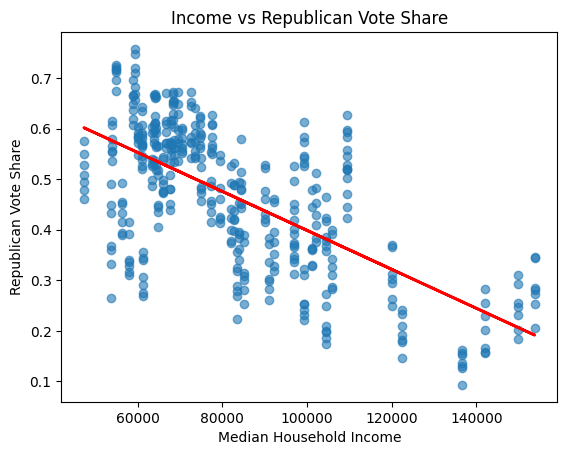

In [15]:
import numpy as np
import matplotlib.pyplot as plt

x = df["median_household_income"]
y = df["rep_share"]

# Scatter
plt.scatter(x, y, alpha=0.6)

# Trend line
m, b = np.polyfit(x, y, 1)
plt.plot(x, m*x + b, color='red', linewidth=2)

# Labels
plt.xlabel("Median Household Income")
plt.ylabel("Republican Vote Share")
plt.title("Income vs Republican Vote Share")

plt.show()

There is a clear negative relationship between income and Republican vote share, meaning higher-income counties tend to vote less Republican.

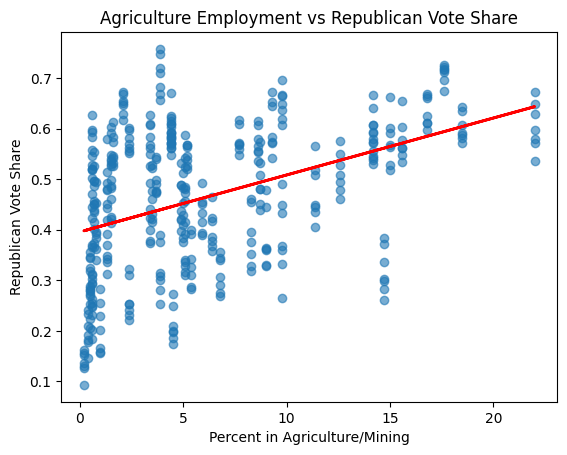

In [16]:
import numpy as np
import matplotlib.pyplot as plt

x = df["pct_agriculture_mining"]
y = df["rep_share"]

# Scatter
plt.scatter(x, y, alpha=0.6)

# Trend line
m, b = np.polyfit(x, y, 1)
plt.plot(x, m*x + b, color='red', linewidth=2)

# Labels
plt.xlabel("Percent in Agriculture/Mining")
plt.ylabel("Republican Vote Share")
plt.title("Agriculture Employment vs Republican Vote Share")

plt.show()

There is a clear positive relationship between agricultural employment and Republican vote share. Counties with higher percentages of people working in agriculture tend to vote more Republican. This supports the idea that more rural, agriculture-based economies are associated with stronger Republican support

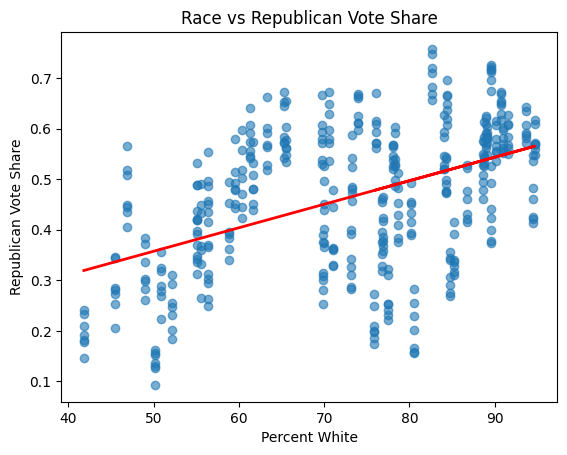

In [19]:
x = df["pct_white"]
y = df["rep_share"]

plt.scatter(x, y, alpha=0.6)

m, b = np.polyfit(x, y, 1)
plt.plot(x, m*x + b, color='red', linewidth=2)

plt.xlabel("Percent White")
plt.ylabel("Republican Vote Share")
plt.title("Race vs Republican Vote Share")

plt.show()

We also see a positive relationship between the percentage of white residents and Republican vote share. Counties with higher white populations tend to vote more Republican

In [18]:
variables = ["median_age", "median_household_income", "pct_white", "pct_agriculture_mining"]

for var in variables:
    print(var, df[var].corr(df["rep_share"]))

median_age 0.152759750176392
median_household_income -0.6696326224206147
pct_white 0.47666860932714805
pct_agriculture_mining 0.43234865380910026


We find that income has the strongest relationship with Republican vote share, with higher-income counties tending to vote less Republican. Race and industry also show moderate positive relationships, while age has only a weak effect. Overall, these results suggest that economic and demographic factors play a key role in shaping voting patterns across counties